In [2]:
import pandas as pd

df = pd.read_csv("payroll_dataset_fixed.csv")

In [3]:
y = df["anomaly_label"]

In [4]:
X = df.drop(columns=[
    "employee_id",
    "anomaly_label"
])

In [5]:
leaky_features = [
    "expected_salary",
    "salary_deviation",
    "salary_deviation_ratio",
    "bonus_ratio",
    "deduction_ratio"
]

X_clean = X.drop(columns=leaky_features)

In [6]:
X_clean = pd.get_dummies(
    X_clean,
    columns=["gender", "department", "employment_type"],
    drop_first=True
)

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [9]:
y_pred = rf_model.predict(X_test)

In [10]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.99      0.96       183
           1       0.50      0.06      0.11        17

    accuracy                           0.92       200
   macro avg       0.71      0.53      0.53       200
weighted avg       0.88      0.92      0.88       200

[[182   1]
 [ 16   1]]


In [11]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [12]:
# Predict probabilities
y_probs = rf_model.predict_proba(X_test)[:, 1]

# Adjust threshold
y_pred = (y_probs > 0.3).astype(int)

# Evaluate
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.99      0.96       183
           1       0.50      0.12      0.19        17

    accuracy                           0.92       200
   macro avg       0.71      0.55      0.57       200
weighted avg       0.89      0.92      0.89       200

[[181   2]
 [ 15   2]]


In [13]:
y_probs = rf_model.predict_proba(X_test)[:, 1]

y_pred = (y_probs > 0.2).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.95      0.94       183
           1       0.25      0.18      0.21        17

    accuracy                           0.89       200
   macro avg       0.59      0.56      0.57       200
weighted avg       0.87      0.89      0.88       200

[[174   9]
 [ 14   3]]


In [14]:
y_probs = rf_model.predict_proba(X_test)[:, 1]

y_pred = (y_probs > 0.25).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.98      0.95       183
           1       0.33      0.12      0.17        17

    accuracy                           0.91       200
   macro avg       0.63      0.55      0.56       200
weighted avg       0.87      0.91      0.88       200

[[179   4]
 [ 15   2]]


In [17]:
import shap
import matplotlib.pyplot as plt
explainer = shap.TreeExplainer(rf_model)


In [18]:
shap_values = explainer.shap_values(X_test)

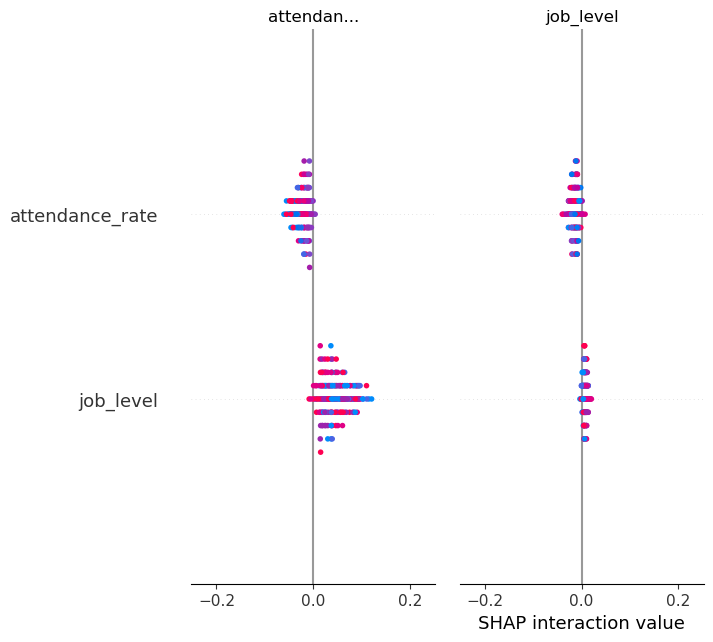

In [19]:
shap.summary_plot(
    shap_values,
    X_test,
    max_display=10,
    show=False
)

plt.gcf().set_size_inches(30, 6)
plt.show()

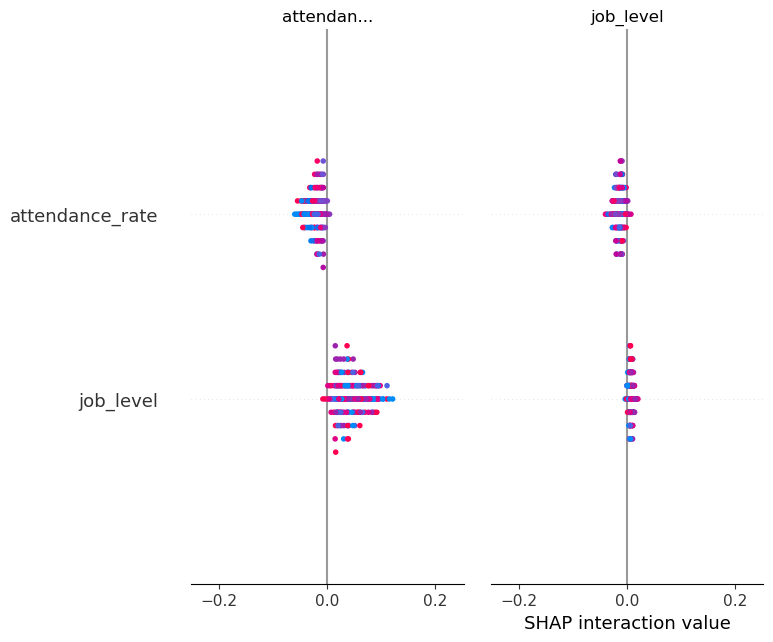

In [20]:
shap.summary_plot(
    shap_values,
    X_test,
    max_display=10,
    show=False
)

import matplotlib.pyplot as plt
plt.gcf().set_size_inches(30, 6)
plt.gcf().subplots_adjust(left=0.01)
plt.show()

In [21]:
pip install fairlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 2.8 MB/s  0:00:13a 0:00:01m eta 0:00:01m
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3━━━━━━━━━━━ 0/2 [scipy]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [fairlearn]━ 1/2 [fairlearn]
Note: you may need to restart the kernel to use updated packages.


In [22]:
from fairlearn.metrics import MetricFrame, selection_rate, demographic_parity_difference
from sklearn.metrics import accuracy_score

In [25]:
sensitive_gender = df.loc[X_test.index, "gender"]
sensitive_department = df.loc[X_test.index, "department"]

In [26]:
metric_gender = MetricFrame(
    metrics={
        "accuracy": accuracy_score,
        "selection_rate": selection_rate
    },
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=sensitive_gender
)

print(metric_gender.by_group)

        accuracy  selection_rate
gender                          
Female  0.892857        0.026786
Male    0.920455        0.034091


In [27]:
from fairlearn.metrics import demographic_parity_difference

dp = demographic_parity_difference(
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=sensitive_gender
)

print(dp)

0.007305194805194804
